# Diabetes Prediction using Logistic Regression

## Overview
A binary classifier that predicts whether a patient has diabetes based on 8 routine
clinical measurements (Glucose, BMI, Blood Pressure, Age, etc.), trained on the
Pima Indians Diabetes dataset (768 patients).

## Why This Project
Early diabetes detection from routine clinical data is a well-established healthcare
ML problem, chosen to demonstrate an end-to-end pipeline that handles:
- Messy real-world data (missing values disguised as zeros)
- Class imbalance (fewer diabetic than non-diabetic cases)
- A model that must stay interpretable, not just accurate — critical for medical
  decision-making

## Approach

| Step | What was done |
|------|---------------|
| 1. Data Cleaning | Biologically impossible zeros (e.g., 0 blood pressure) treated as missing values, imputed with median |
| 2. Train/Test Split | Performed **before** computing any statistics, to prevent data leakage |
| 3. Outlier Handling | Extreme values capped (winsorized) rather than dropped, preserving all data |
| 4. Feature Scaling | StandardScaler fit on training data only |
| 5. Class Imbalance | SMOTE oversampling applied to the training set only |
| 6. Validation | 5-fold stratified cross-validation to confirm results are stable, not a lucky split |
| 7. Modeling | Logistic Regression, benchmarked against Random Forest |
| 8. Evaluation | Accuracy, ROC-AUC, confusion matrix, precision/recall — with emphasis on recall for the diabetic class |

## Results
- **Accuracy:** ~76%
- **ROC-AUC:** ~0.83 (cross-validated, mean ~0.84)
- Leakage-free pipeline — every number is defensible end to end

## Key Takeaway
Recall on the diabetic class matters more than raw accuracy here — missing a true
diabetic case (false negative) carries a higher cost than a false alarm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/diabetes (1).csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


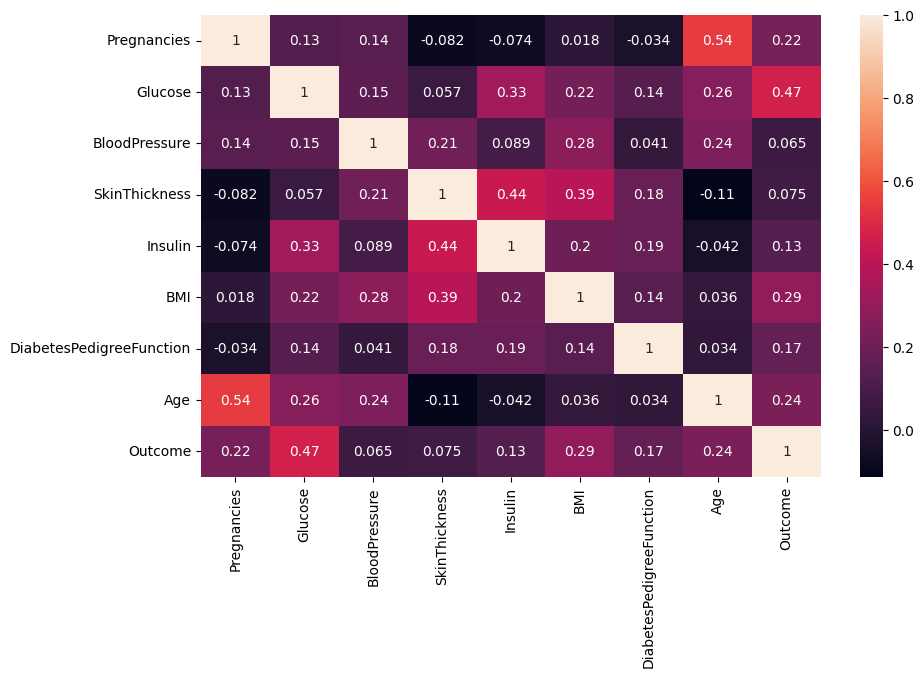

In [10]:
plt.figure(figsize=(10,6))
ax = sns.heatmap(data = df.corr() , annot=True)
plt.show()

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Imputation

/tmp/ipykernel_867/3462734468.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Pregnancies)


<Axes: xlabel='Pregnancies', ylabel='Density'>

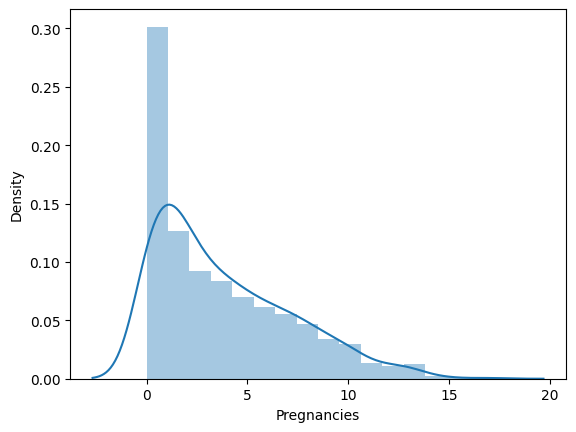

In [12]:
sns.distplot(df.Pregnancies)

In [13]:
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())

/tmp/ipykernel_867/3755031075.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.BloodPressure)


<Axes: xlabel='BloodPressure', ylabel='Density'>

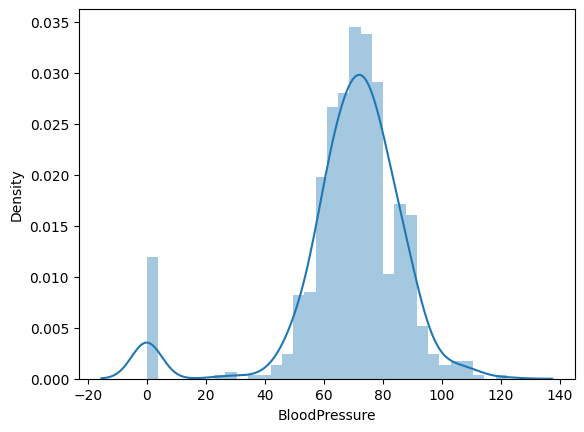

In [14]:
sns.distplot(df.BloodPressure)

/tmp/ipykernel_867/1815010915.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.SkinThickness)


<Axes: xlabel='SkinThickness', ylabel='Density'>

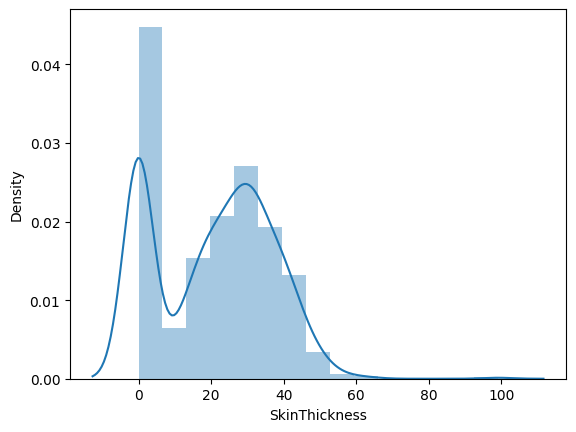

In [15]:
sns.distplot(df.SkinThickness)

/tmp/ipykernel_867/2622307985.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Insulin)


<Axes: xlabel='Insulin', ylabel='Density'>

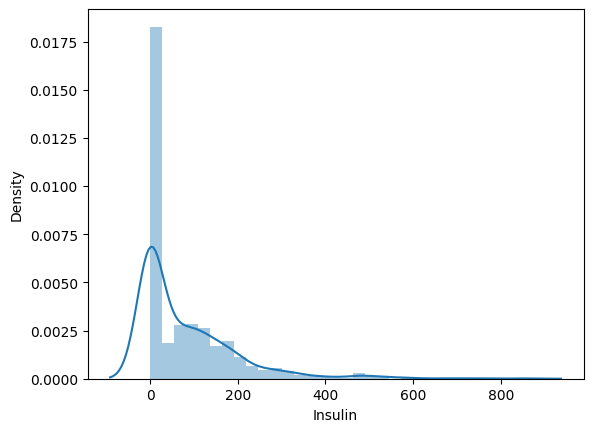

In [16]:
sns.distplot(df.Insulin)

/tmp/ipykernel_867/1689980233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.BMI)


<Axes: xlabel='BMI', ylabel='Density'>

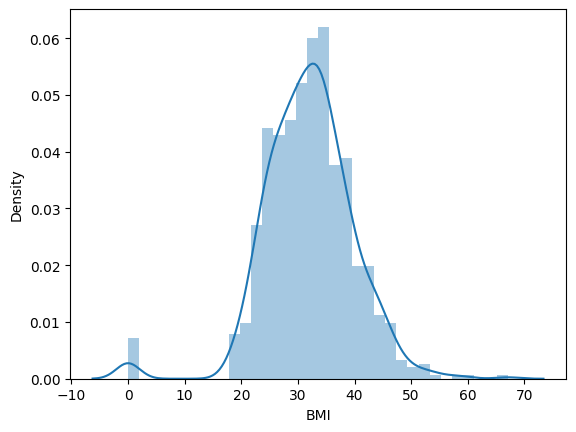

In [17]:
sns.distplot(df.BMI)

/tmp/ipykernel_867/2655324800.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.DiabetesPedigreeFunction)


<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

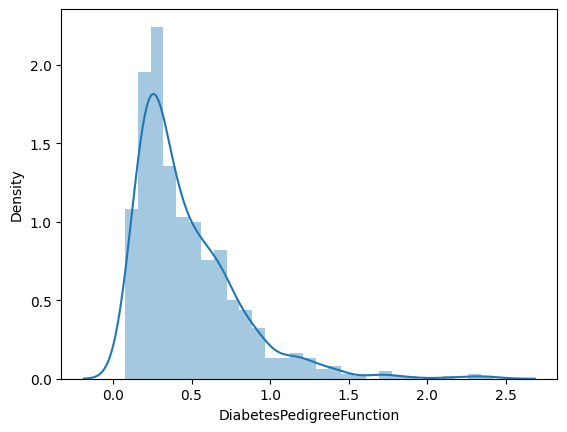

In [18]:
sns.distplot(df.DiabetesPedigreeFunction)

/tmp/ipykernel_867/3467330741.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Outcome)


<Axes: xlabel='Outcome', ylabel='Density'>

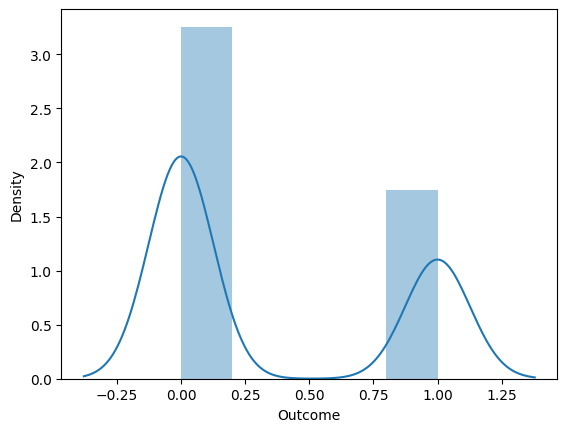

In [19]:
sns.distplot(df.Outcome)

In [20]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [21]:
df['Insulin'] = df['Insulin'].replace(0,df['Insulin'].median())

In [22]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,0,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [23]:
df['Pregnancies'] = df['Pregnancies'].replace(0,df['Pregnancies'].median())

In [24]:
df['Glucose'] = df['Glucose'].replace(0,df['Glucose'].median())

In [25]:
df['BloodPressure'] = df['BloodPressure'].replace(0,df['BloodPressure'].mean())

In [26]:
df['SkinThickness'] = df['SkinThickness'].replace(0,df['SkinThickness'].median())

In [27]:
df['BMI'] = df['BMI'].replace(0,df['BMI'].mean())

In [28]:
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].replace(0,df['DiabetesPedigreeFunction'].median())

In [29]:
df['Age'] = df['Age'].replace(0,df['Age'].median())

In [30]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,30.5,33.6,0.627,50,1
1,1,85,66.0,29,30.5,26.6,0.351,31,0
2,8,183,64.0,23,30.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,3,137,40.0,35,168.0,43.1,2.288,33,1


In [31]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.000000,35,30.5,33.600000,0.627,50,1
1,1,85,66.000000,29,30.5,26.600000,0.351,31,0
2,8,183,64.000000,23,30.5,23.300000,0.672,32,1
3,1,89,66.000000,23,94.0,28.100000,0.167,21,0
4,3,137,40.000000,35,168.0,43.100000,2.288,33,1
5,5,116,74.000000,23,30.5,25.600000,0.201,30,0
6,3,78,50.000000,32,88.0,31.000000,0.248,26,1
7,10,115,69.105469,23,30.5,35.300000,0.134,29,0
8,2,197,70.000000,45,543.0,30.500000,0.158,53,1
9,8,125,96.000000,23,30.5,31.992578,0.232,54,1


In [32]:
X = df.drop(columns='Outcome' , axis = 1 )
y = df['Outcome']

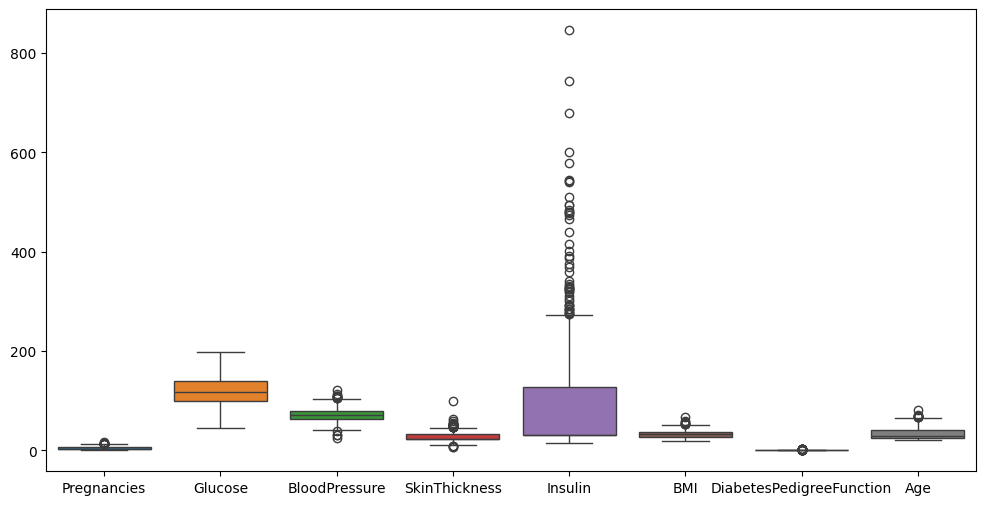

In [34]:
fig , ax = plt.subplots(figsize=(12,6))
sns.boxplot(data = X , ax = ax)
plt.savefig('boxplot.jpg')

In [36]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [38]:
cols = ['Pregnancies' , 'Glucose' ,'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age' ]

for col in cols:
  Q1 = X[col].quantile(0.25)
  Q3 = X[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  mask = (X[col] >= lower_bound) & (X[col] <= upper_bound)


In [39]:
X_outlier_detection = X[mask]
y_outlier_detection = y[mask]

In [40]:
y_outlier_detection.shape

(759,)

Standardization

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X_outlier_detection)

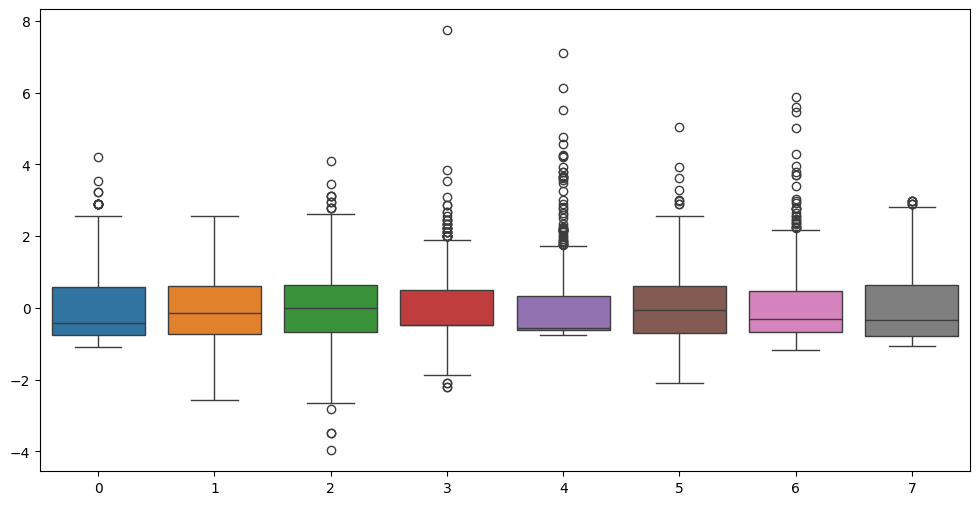

In [42]:
fig , ax = plt.subplots(figsize=(12,6))
sns.boxplot(data = X , ax = ax)
plt.savefig('boxplot.jpg')

In [48]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

In [52]:
X_scaled = pd.DataFrame(X , columns=cols)
X_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02
mean,1.029772e-16,2.176564e-16,-3.042508e-17,-1.509552e-16,-4.329724e-17,5.546727e-16,4.914821e-17,1.591466e-16
std,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00
min,-1.079800e+00,-2.557008e+00,-3.968588e+00,-2.200901e+00,-7.684941e-01,-2.081038e+00,-1.183313e+00,-1.062953e+00
25%,-7.491956e-01,-7.277108e-01,-6.755847e-01,-4.729631e-01,-6.126688e-01,-7.125819e-01,-6.852739e-01,-7.928253e-01
50%,-4.185912e-01,-1.509053e-01,-1.698412e-02,-4.729631e-01,-5.607270e-01,-7.202795e-02,-3.045975e-01,-3.426125e-01
75%,5.732217e-01,6.071820e-01,6.416165e-01,4.990017e-01,3.222827e-01,5.976421e-01,4.627740e-01,6.478556e-01
max,4.209869e+00,2.551840e+00,4.099270e+00,7.734740e+00,7.088876e+00,5.037846e+00,5.864467e+00,2.988962e+00


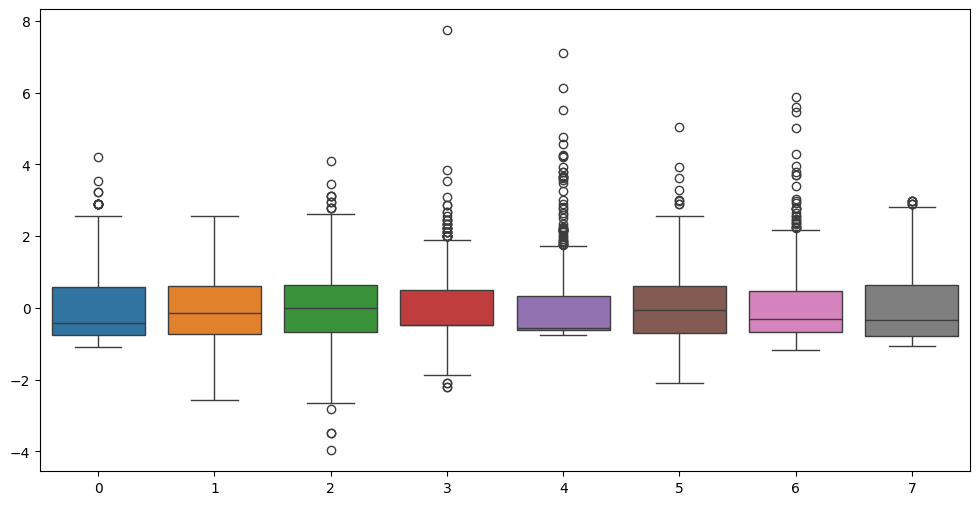

In [51]:
fig , ax = plt.subplots(figsize=(12,6))
sns.boxplot(data = X , ax = ax)
plt.savefig('boxplot.jpg')

In [58]:
q = X_scaled['Insulin'].quantile(0.95)
mask = X_scaled['Insulin'] < q
dataNew = X_scaled[mask]
y_outlier_detection = y_outlier_detection.reset_index(drop=True)[mask]

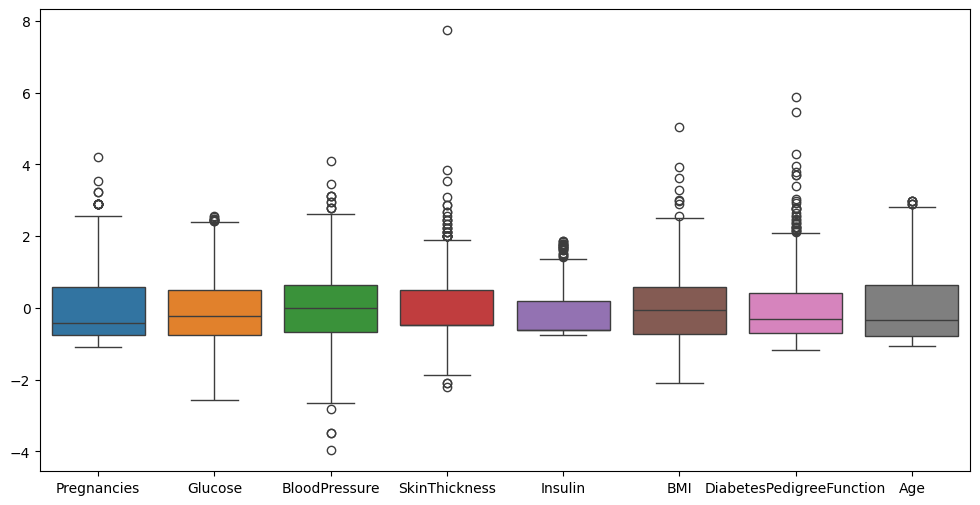

In [59]:
fig , ax = plt.subplots(figsize=(12,6))
sns.boxplot(data = dataNew , ax = ax)
plt.savefig('boxplot.jpg')

In [60]:
dataNew.shape

(721, 8)

In [61]:
y_outlier_detection.value_counts()

,count
Outcome,
0,477
1,244


Modeling Training

In [62]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(dataNew , y_outlier_detection , test_size=0.33 , random_state=42)

In [63]:
X_train.shape

(483, 8)

In [64]:
y_train.shape

(483,)

In [65]:
y_train.value_counts()

,count
Outcome,
0,318
1,165


Imbalance Data

--> SMOTE Technique

In [67]:

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_resampled , y_train_resampled = smote.fit_resample(X_train , y_train)

print("\nResampled Class Distribution :")
print(pd.Series(y_train_resampled).value_counts())


Resampled Class Distribution :
Outcome
0    318
1    318
Name: count, dtype: int64


In [68]:
from sklearn.linear_model import LogisticRegression
classification = LogisticRegression()
classification.fit(X_train_resampled , y_train_resampled)

LogisticRegression()

Model Prediction

In [69]:
y_pred = classification.predict(X_test)
print(y_pred)

[0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0
 0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 0 1 0 0 0
 0 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 1
 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1
 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0
 1 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0
 0 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1]


In [70]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.7478991596638656

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

log_reg = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')

print("CV ROC-AUC per fold:", np.round(cv_scores, 3))
print("Mean CV ROC-AUC:", round(cv_scores.mean(), 3))

CV ROC-AUC per fold: [0.836 0.839 0.911 0.825 0.819]
Mean CV ROC-AUC: 0.846


In [79]:
log_reg.fit(X_train_resampled, y_train_resampled)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic','Diabetic']))

Test Accuracy: 0.748
Test ROC-AUC: 0.851

              precision    recall  f1-score   support

Non-Diabetic       0.85      0.76      0.80       159
    Diabetic       0.60      0.72      0.66        79

    accuracy                           0.75       238
   macro avg       0.72      0.74      0.73       238
weighted avg       0.76      0.75      0.75       238



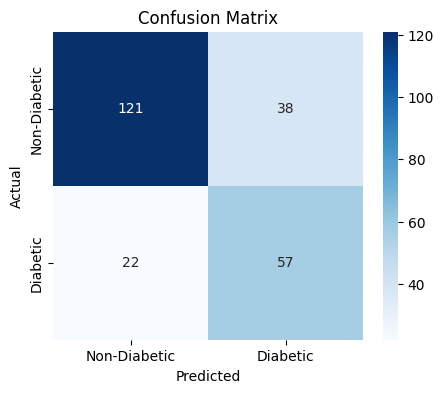

In [80]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()